In [26]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
import typer
import uproot
import gp
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import openpyxl
import math
    
rebin = 2;
mass_hypothesis = .035
# Coefficients for the polynomial from the table for unsmeared (P0 to P4)
coefficients = [0.00032, 0.019, -0.11, 1.39, -4.33] #2016 10%
#coefficients = [-6.166,.9069,-0.00297,0.000579,0];
#coefficients = [0.000579,-0.00297,0.9069,-6.166];
#smeared
#coefficients = [0.00038,0.041,-0.27,3.49,-11.11]

events = 1000;
num_sigma = 1.5;

def sig_width(mass, coeffs):
    #sigma is twice the mass resolution
    return sum(c * mass**i for i, c in enumerate(coeffs))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
# no signal
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179)

)
thirty_five_mev_plots = pd.DataFrame({"no injected signal" : m.pull})
fifty_eight_mev_plots = pd.DataFrame({"no injected signal" : m.pull})
seventy_five_mev_plots = pd.DataFrame({"no injected signal" : m.pull})
one_hundred_mev_plots = pd.DataFrame({"no injected signal" : m.pull})
one_hundred_fifty_mev_plots = pd.DataFrame({"no injected signal" : m.pull})

In [28]:
# 1000 events at 35 MeV
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
thirty_five_mev_plots["1000 events"] = m.pull

In [29]:
# 3000 events at 35 MeV
events = 3000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
thirty_five_mev_plots["3000 events"] = m.pull

In [30]:
# 5000 events at 35 MeV
events = 5000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
thirty_five_mev_plots["5000 events"] = m.pull

In [31]:
# 10000 events at 35 MeV
events = 10000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-(num_sigma*sig_width(mass_hypothesis, coefficients)), mass_hypothesis+(num_sigma*sig_width(mass_hypothesis, coefficients))),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
thirty_five_mev_plots["10000 events"] = m.pull

Text(0.5, 1.0, 'Signal Injected at 35 MeV, 1.5 sigma')

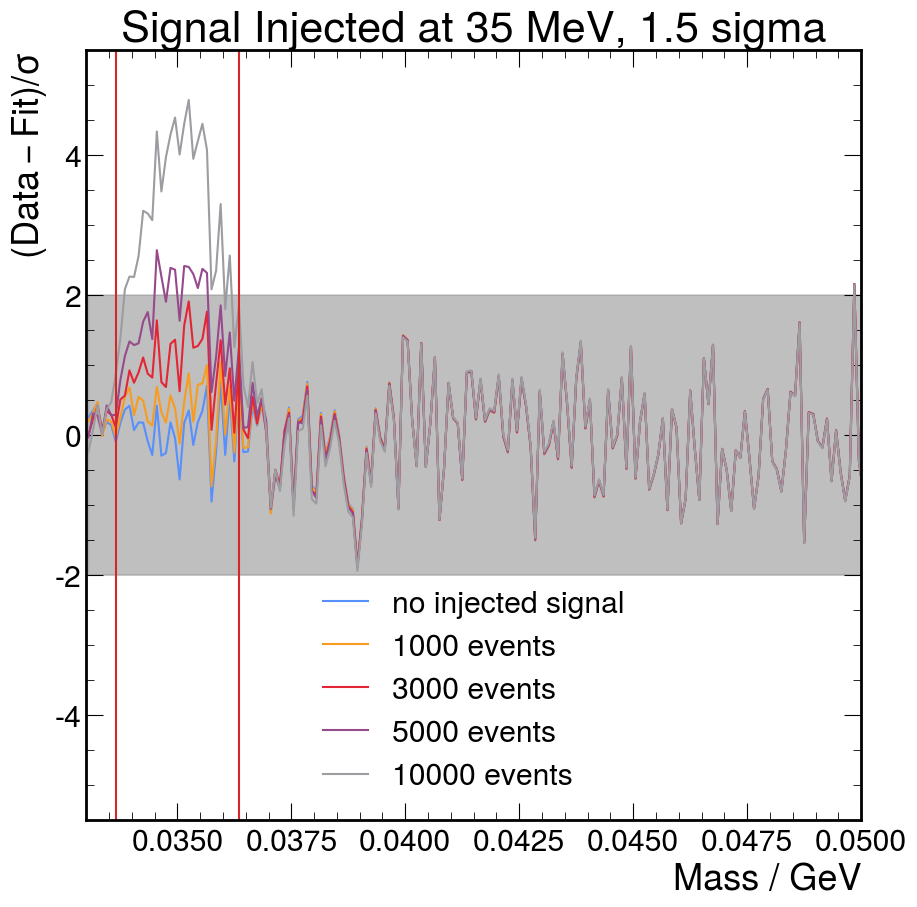

In [34]:
x = m.histogram.axes[0].centers[m.positive_prediction]
plt.plot(x, thirty_five_mev_plots)
plt.fill_between(
    x, np.full(x.shape, -2), np.full(x.shape, +2),
    color='gray', alpha=0.5
)
plt.legend(thirty_five_mev_plots.columns)
plt.ylabel(r'$(\mathrm{Data} - \mathrm{Fit})/\sigma$')
plt.xlabel("Mass / GeV")
plt.ylim(-5.5,5.5)
for e in m.blind_range:
    plt.axvline(e, color='tab:red')
plt.xlim(.033, .05)
plt.title("Signal Injected at 35 MeV, " + str(num_sigma) + " sigma")

In [ ]:
# no signal at 58 MeV
mass_hypothesis = 0.058
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179)

)

In [ ]:
# 1000 events at 58 MeV
events = 1000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
fifty_eight_mev_plots["1000 events"] = m.pull

In [ ]:
# 3000 events at 58 MeV
events = 3000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
fifty_eight_mev_plots["3000 events"] = m.pull

In [ ]:
# 5000 events at 58 MeV
events = 5000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
fifty_eight_mev_plots["5000 events"] = m.pull

In [ ]:
# 10000 events at 58 MeV
events = 10000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
fifty_eight_mev_plots["10000 events"] = m.pull

In [ ]:
plt.plot(x, fifty_eight_mev_plots)
plt.fill_between(
    x, np.full(x.shape, -2), np.full(x.shape, +2),
    color='gray', alpha=0.5
)
plt.legend(fifty_eight_mev_plots.columns)
plt.ylabel(r'$(\mathrm{Data} - \mathrm{Fit})/\sigma$')
plt.xlabel("Mass / GeV")
plt.ylim(-5.5,5.5)
for e in m.blind_range:
    plt.axvline(e, color='tab:red')
plt.xlim(.052, .064)
plt.title("Signal Injected at 58 MeV, 2 sigma width")

In [ ]:
# no signal at 75 MeV
mass_hypothesis = 0.075
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179)

)

In [ ]:
# 1000 events at 75 MeV
events = 1000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
seventy_five_mev_plots["1000 events"] = m.pull

In [ ]:
# 3000 events at 75 MeV
events = 3000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
seventy_five_mev_plots["3000 events"] = m.pull

In [ ]:
# 5000 events at 75 MeV
events = 5000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
seventy_five_mev_plots["5000 events"] = m.pull

In [ ]:
# 10000 events at 75 MeV
events = 10000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
seventy_five_mev_plots["10000 events"] = m.pull

In [ ]:
plt.plot(x, seventy_five_mev_plots)
plt.fill_between(
    x, np.full(x.shape, -2), np.full(x.shape, +2),
    color='gray', alpha=0.5
)
plt.legend(seventy_five_mev_plots.columns)
plt.ylabel(r'$(\mathrm{Data} - \mathrm{Fit})/\sigma$')
plt.xlabel("Mass / GeV")
plt.ylim(-5.5,5.5)
for e in m.blind_range:
    plt.axvline(e, color='tab:red')
plt.xlim(.068, .082)
plt.title("Signal Injected at 75 MeV")

In [ ]:
# no signal at 100 MeV
mass_hypothesis = 0.100
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179)

)

In [ ]:
# 1000 events at 100 MeV
mass_hypothesis = 0.100
events = 1000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)

one_hundred_mev_plots["1000 events"] = m.pull

In [ ]:
# 3000 events at 100 MeV
events = 3000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
one_hundred_mev_plots["3000 events"] = m.pull

In [ ]:
# 5000 events at 100 MeV
events = 5000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
one_hundred_mev_plots["5000 events"] = m.pull

In [ ]:
# 10000 events at 100 MeV
events = 10000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-num_sigma*sig_width(mass_hypothesis, coefficients), mass_hypothesis+num_sigma*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
one_hundred_mev_plots["10000 events"] = m.pull

In [ ]:
plt.plot(x, one_hundred_mev_plots)
plt.fill_between(
    x, np.full(x.shape, -2), np.full(x.shape, +2),
    color='gray', alpha=0.5
)
plt.legend(one_hundred_mev_plots.columns)
plt.ylabel(r'$(\mathrm{Data} - \mathrm{Fit})/\sigma$')
plt.xlabel("Mass / GeV")
plt.ylim(-5.5,5.5)
for e in m.blind_range:
    plt.axvline(e, color='tab:red')
plt.xlim(.090, .110)
plt.title("Signal Injected at 100 MeV")

In [ ]:
# no signal at 150 MeV
mass_hypothesis = 0.150
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-2*sig_width(mass_hypothesis, coefficients), mass_hypothesis+2*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179)

)

In [ ]:
# 1000 events at 150 MeV
events = 1000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-2*sig_width(mass_hypothesis, coefficients), mass_hypothesis+2*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
one_hundred_fifty_mev_plots["1000 events"] = m.pull

In [ ]:
# 3000 events at 150 MeV
events = 3000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-2*sig_width(mass_hypothesis, coefficients), mass_hypothesis+2*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
one_hundred_fifty_mev_plots["3000 events"] = m.pull

In [ ]:
# 5000 events at 150 MeV
events = 5000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-2*sig_width(mass_hypothesis, coefficients), mass_hypothesis+2*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
one_hundred_fifty_mev_plots["5000 events"] = m.pull

In [ ]:
# 10000 events at 150 MeV
events = 10000;
m = gp.GaussianProcessModel(
    h = ('EventSelection_Data_10Percent.root', 'h_Minv_General_Final_1'), #2016 10%
    kernel = gp.kernels.WhiteKernel(noise_level=7e3) + gp.kernels.RBF(length_scale = 0.016)*gp.kernels.DotProduct(sigma_0 = 2.5e4),
    blind_range = (mass_hypothesis-2*sig_width(mass_hypothesis, coefficients), mass_hypothesis+2*sig_width(mass_hypothesis, coefficients)),
    modify_histogram = [gp._hist.manipulation.rebin_and_limit(rebin, 0.033, 0.179), gp._hist.manipulation.inject_signal(events, sig_width(mass_hypothesis,coefficients), mass_hypothesis)]

)
one_hundred_fifty_mev_plots["10000 events"] = m.pull

In [ ]:
plt.plot(x, one_hundred_fifty_mev_plots)
plt.fill_between(
    x, np.full(x.shape, -2), np.full(x.shape, +2),
    color='gray', alpha=0.5
)
plt.legend(one_hundred_fifty_mev_plots.columns)
plt.ylabel(r'$(\mathrm{Data} - \mathrm{Fit})/\sigma$')
plt.xlabel("Mass / GeV")
plt.ylim(-5.5,5.5)
for e in m.blind_range:
    plt.axvline(e, color='tab:red')
plt.xlim(.140, .160)
plt.title("Signal Injected at 150 MeV")